# HYDROAWARE-AFRICA project

## CUWALID TRAINING

## DRYP: Creating a catchment scale model

This section (in bold) is part of the CUWALID training material:

1. ***Preparing model input parameters and dataset***
2. Running a catchment scale DRYP model
3. Post-processing DRYP model outputs


### 1. Preprocessing datasets

This section will help you to create all datasets required to develop a regional or nation scale scale model. This section uses datasets from different public repositories. These datasets have been postprocessed to make it consistent with DRYP model requirements. These datasets cover the entire Africa continent so they can be used for any region or basin across Africa.

catchment scale model is based on the regional model parameters created for the Horn of Africa Dryland region (HAD). Therefore, model parameters are only available for the east part of the HAD. If you want to create a new model for an area outside the HAD you will have to create your own set of parameters. Global datasets can be used for initial parameterization, thus, data can be found in repositories such as Hydrosheds, SoilGrids, etc.

The following sections use CUWALID Python functions developed to handle raster datasets and preprocessing model parameters. However, you can create your parameters with your preferred software or package. CUWALID preprocessing functions perform basic tasks, therefore, complex operations can be performed using any GIS software (e.g. ArcMap, QGis) or Python libraries such as rasterio.

The following steps will be carried out in order to produce a set of gridded model parameters for any basin provided the location of the catchment outlet or streamflow station of interest.

The user may also used shapefile, rasters, or bounding box to select a model domain. Here, we only use a catchment outlet for basin delineation.

1. Specify the location of the region output(s) or pour points
2. Delineate the model domain
3. Clip all raster datasets to match the size of the model domain
4. Prepare JSON parameter and setting files
5. Set forcing datasets
6. Run the model

In [248]:
# Import libraries from a local repository
import os
import sys
#sys.path.append("C:/Users/Edisson/Documents/GitHub/CUWALID") # DELETE THIS LINE AS THE PACKAGE CONTAINS ALL
sys.path.append('/home/c1755103/gitremote/CUWALID')
import cuwalid.dryp.components.DRYP_watershed as ppbasin # component for basin delineation
import cuwalid.tools.DRYP_plot_tools as plotcwld # component to read model input files
import cuwalid.tools.DRYP_pptools as pptools # Component for postprocessing model output files
import cuwalid.tools.DRYP_rrtools as rrtools # Component for preprocessing raster datasets

In [249]:
training_general_path = "C:/Users/Edisson/Documents/GitHub/CUWALID/DRYP_training_data/" # Path to the training data
training_basin_path = os.path.join(training_general_path, "basin_delineation/") # Path to the basin delineation training data
training_basin_raster_path = os.path.join(training_basin_path, "rasters/") # Path to the rasters for basin delineation training
training_basin_vector_path = os.path.join(training_basin_path, "vectors/") # Path to the vectors for basin delineation training
training_basin_output_path = os.path.join(training_basin_path, "output/") # Path to the output for basin delineation training

First, let's get a new directory to store all model files

In [250]:
def create_directory_structure(base_dir, name):
    # Define the full directory structure
    directories = [
        os.path.join(base_dir, f'{name}', 'output'),
        os.path.join(base_dir, f'{name}', 'postpp'),
        os.path.join(base_dir, f'{name}', 'postpp', "csv"),
        os.path.join(base_dir, f'{name}', 'postpp', "netcdf"),
        os.path.join(base_dir, f'{name}', 'postpp', 'fig'),
        os.path.join(base_dir, f'{name}', 'postpp', 'raster'),
        os.path.join(base_dir, f'{name}', 'model'),
        os.path.join(base_dir, f'{name}', 'model', 'input'),
        os.path.join(base_dir, f'{name}', 'dataset', 'pre'),
        os.path.join(base_dir, f'{name}', 'dataset', 'pet'),
    ]
    
    # Create each directory if it doesn't exist
    for directory in directories:
        os.makedirs(directory, exist_ok=True)
    
    return directories

Create a directory to store all model files

In [251]:
base_dir = "/home/c1755103/training_mowe/"
name = "AW"
directories = create_directory_structure(base_dir, name)

print ("Directory structure created successfully!")
# print the index and the directories
for i, directory in enumerate(directories):
    print(f"{i}: {directory}")  


Directory structure created successfully!
0: /home/c1755103/training_mowe/AW/output
1: /home/c1755103/training_mowe/AW/postpp
2: /home/c1755103/training_mowe/AW/postpp/csv
3: /home/c1755103/training_mowe/AW/postpp/netcdf
4: /home/c1755103/training_mowe/AW/postpp/fig
5: /home/c1755103/training_mowe/AW/postpp/raster
6: /home/c1755103/training_mowe/AW/model
7: /home/c1755103/training_mowe/AW/model/input
8: /home/c1755103/training_mowe/AW/dataset/pre
9: /home/c1755103/training_mowe/AW/dataset/pet


Second, we will a set of ready-to-use parameters prepared for this training, so let's add this to the workflow:

In [252]:
# Define the path to the global parameters JSON file
fname = "/home/c1755103/AF/dataset/postpp/af_global_parameters.json"

In [253]:
# read the json file with the parameters for the basin delineation
import json
with open(fname, "r") as f:
    params = json.load(f)

print('---------------------------------------------')
print('List of parameters at continental scale')
print('---------------------------------------------')
params

---------------------------------------------
List of parameters at continental scale
---------------------------------------------


{'TERRAIN': {'path_dem': '/home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif',
  'path_Qo': None,
  'path_fdl': '/home/c1755103/AF/dataset/raw/hyd_af_dir_30s.tif',
  'path_riv_decay': None,
  'path_mask': '/home/c1755103/AF/dataset/raw/hyd_af_msk_30s.tif',
  'path_riv_len': '/home/c1755103/AF/dataset/postpp/af_river_length_30s.tif',
  'path_riv_width': '/home/c1755103/AF/dataset/postpp/af_river_width_30s.tif',
  'path_riv_elev': '/home/c1755103/AF/dataset/postpp/af_dem_30s_q1.tif',
  'path_of_bc_flux': None,
  'path_acc': '/home/c1755103/AF/dataset/raw/hyd_af_acc_30s.tif'},
 'UNSATURATED': {'path_uz_theta_sat': '/home/c1755103/AF/dataset/postpp/af_theta_s_l1.tif',
  'path_uz_theta_awc': '/home/c1755103/AF/dataset/postpp/af_theta_available_water_content.asc',
  'path_uz_theta_wp': '/home/c1755103/AF/dataset/postpp/af_theta_wilting_point.asc',
  'path_uz_rootdepth': '/home/c1755103/AF/dataset/postpp/gyga_af_agg_erzd_pwp__m_1km_reprojected.tif',
  'path_uz_lambda': '/home/c1755103/AF/datase

### Let's start building our model

There are different options, so we will explore some of them.

#### 1. Specify a model domain

Create an example file of basin pour points

In [254]:
outlet = {'East': 41.19, 'North': 8.73} # outlet coordinates for the Awash and Genale basins, respectively

In [255]:
# create a dataframe from the dictionary and save it as a csv file
import pandas as pd
df_outlet = pd.DataFrame([outlet])
# save the dataframe as a csv file in the output directory
fname_outlet = os.path.join(directories[7], "test_outlet.csv")
df_outlet.to_csv(fname_outlet, index=False)

df_outlet

,East,North
0,41.19,8.73


2. Basin delineation

Read the list of high resolution continental scale dataset that can be used to delineate the basin

Option 1: Create a basin using a DRYP flow direction map, and the csv pour points.

In [256]:
# specify the path of the new basin mask file that will be created with the AF flow direction file as input
fname_out_dryp = os.path.join(directories[7], "af_test_basin_mask_dryp.tif")

In [257]:
# create a raster flow direction file in the format that is the most convenient for DRYP
path_af_fld_dryp = os.path.join(directories[7], "af_test_fld_dryp.tif")
# create the raster flow direction file in the format that is the most convenient for DRYP
rrtools.create_raster_flowdirection_dryp(params['TERRAIN']['path_fdl'], path_af_fld_dryp, translate=True)

Transforming flow direction from  D8  format to DRYP landlab format


In [258]:
# run the basin delineation function using a flow direction file in the format that is the most convenient for DRYP as input
ppbasin.get_watershed_mask(params['TERRAIN']['path_dem'],
                           fname_outlet, fname_flowDir=path_af_fld_dryp,
                           fname_out=fname_out_dryp)#, flowdir_format='D8')

Option 2: Create a mask using a D8 flow direction map directly and the csv file of pour points

In [259]:
path_rgn_mask = os.path.join(directories[7], "af_test_basin_mask.tif")

In [260]:
# run the basin delineation function
ppbasin.get_watershed_mask(params['TERRAIN']['path_dem'],
                           fname_outlet, fname_flowDir=params['TERRAIN']['path_fdl'],
                           fname_out=path_rgn_mask, flowdir_format='D8')

Transforming flow direction from  D8  format to DRYP landlab format


Option 3: Create a basin domain using only a shapefile

In [261]:
# name of the shapefile to rasterize
path_shp = "/home/c1755103/training_mowe/AW/dataset/awash_hybas_af_lev04_v1c.shp"
path_shp = "/home/c1755103/training_mowe/AW/dataset/genale_hybas_af_lev04_v1c.shp"

In [262]:
# fname of the output raster mask
fname_out_from_shapefile = os.path.join(directories[7], "af_test_basin_mask_from_shapefile.tif")

In [263]:
# rasterize the shapefile to create a raster mask of the basin
rrtools.create_raster_from_shapefile(path_shp, params['TERRAIN']['path_dem'], fname_out_from_shapefile)

To delineate the basin you can provide DEM only, however, providing the flow direction map either in DRYP or D8 direction map may yield better results.

**We recommend providing the flow direction map as it may yield better results.**

Specify the path of the output file, if it is not provided, the default value None will be uses and the function will automatically generate a name by adding the the word *_basin* at the end of the surface input file


The output of this function is a raster file. **Remember**, If the name of the output file, *fname_out* is not provided, this file will be stored in the same directory as the surface file and it will have the same name as the surface (input file) but added "*_basin*" at the end.

Plot the map containing the basin mask

In [264]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import plotting_extent

# Open the file
def plot_raster_file(fname, vmin=None, vmax=None, ax=None, show_colorbar=False, colorbar_label=None, title=None):
    # create plot
    if ax is None:
        fig, ax = plt.subplots()

    with rasterio.open(fname) as dataset:
        band = dataset.read(1)
        extent = plotting_extent(dataset)
        im = ax.imshow(band, extent=extent, cmap='viridis', vmin=vmin, vmax=vmax)
        if title is not None:
            ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax)
        if colorbar_label is not None:
            cbar.set_label(colorbar_label)

    return ax

<Axes: title={'center': 'Basin mask from flow direction file'}>

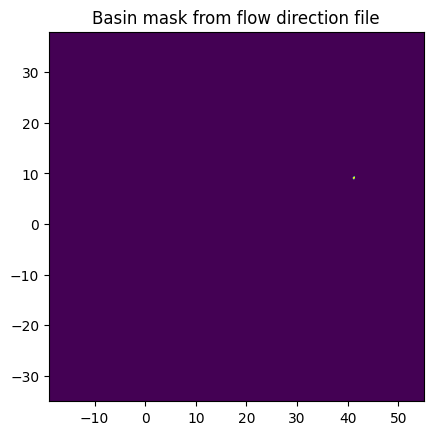

In [265]:
plot_raster_file(path_rgn_mask, title="Basin mask from flow direction file")
#plot_raster_file(fname_out_dryp)
#plot_raster_file(fname_out_from_shapefile)

This step is not necesary, but it may help you to identify potential errors in your flow direction maps and basins.

Get flow accumulatio map and areas table

In [266]:
# specify the path of the new basin accumulation file that will be created with the AF flow direction file as input
fname_out_access = os.path.join(directories[7], "af_test_basin_accum.tif")

You can also calculate the area of the basin by using the following function and the basin mask, created in the previous step. The output file is a *.CSV file and the name, if not provided, will be the name of the input file added *_area* at the end the file.

In [267]:
# Run fuction to calculate the area of the basin
ppbasin.get_watershed_area(params['TERRAIN']['path_dem'], fname_outlet,
                           fname_flowDir=params['TERRAIN']['path_fdl'],
                           fname_mask=params['TERRAIN']['path_mask'],
                           flowdir_format='D8', fname_out=fname_out_access)

Transforming flow direction from  D8  format to DRYP landlab format


/home/c1755103/gitremote/CUWALID/cuwalid/dryp/components/DRYP_flow_accum.py:282: RuntimeWarning: invalid value encountered in divide
  self.par_4 = 2.0*Ksat/(decay*riv_width)
/home/c1755103/gitremote/CUWALID/cuwalid/dryp/components/DRYP_flow_accum.py:286: RuntimeWarning: invalid value encountered in divide
  self.par_3 = Ksat*riv_width*riv_length/(riv_width-2*Ksat)


Watershed area and contributing area map saved:
/home/c1755103/training_mowe/AW/model/input/af_test_basin_accum_areas.csv, /home/c1755103/training_mowe/AW/model/input/af_test_basin_accum.tif_flowaccum.asc


**TASK** Read the csv file created in the previous state to check the catchment area

**TASK**: Visualize the created datasets

#### 2. Create the basin model domain

The new model domain can be created by clipping the regional datasets by the extent of the newly delineated basin.

The following step will clip the raster files by identifying the extent of the basin provided in the mask. The extent is specified by the area containing all positive values of the mask.

In [268]:
# path of the regional mask that will be used for clipping the rasters to the basin extent
#path_rgn_mask = os.path.join(directories[7], "af_test_basin_mask_from_shapefile.tif")
# path of the new basin mask that will be the output of the clipping process
path_bsn_mask = os.path.join(directories[7], "aw_test_basin_mask.tif")


First, an example using only one file is created by clipping the model domain of a selected file:

In [269]:
# reduce the size of the basin by clipping the exted of the mask from the regional raster file
rrtools.clip_raster_by_mask(path_rgn_mask, path_rgn_mask, path_bsn_mask)

In [270]:
# clipping dem and flow direction rasters to the basin extent
path_bsn_dem = os.path.join(directories[7], "aw_test_basin_dem.tif")
path_bsn_fdl = os.path.join(directories[7], "aw_test_basin_fdl.tif")
rrtools.clip_raster_by_mask(params['TERRAIN']['path_dem'], path_rgn_mask, path_bsn_dem)
rrtools.clip_raster_by_mask(params['TERRAIN']['path_fdl'], path_rgn_mask, path_bsn_fdl)

In [271]:
path_bsn_fld_dryp = os.path.join(directories[7], "aw_basin_fld_dryp.tif")
rrtools.create_raster_flowdirection_dryp(path_bsn_fdl, path_bsn_fld_dryp, translate=True)

Transforming flow direction from  D8  format to DRYP landlab format


Check that the new created file contains the basin, so run again the basin deliniation to check if it matches the basin.

You may need the flow direction to perform this task, but you have already clipped that!

In [272]:
# specify the path of the new basin mask that will be the output of the test process
path_bsn_mask_test = os.path.join(directories[7], "aw_test_basin_mask_check.tif")

In [273]:
# run the basin delineation function
ppbasin.get_watershed_mask(path_bsn_dem,
                           fname_outlet, fname_flowDir=path_bsn_fdl,
                           fname_out=path_bsn_mask_test, flowdir_format='D8')

Transforming flow direction from  D8  format to DRYP landlab format


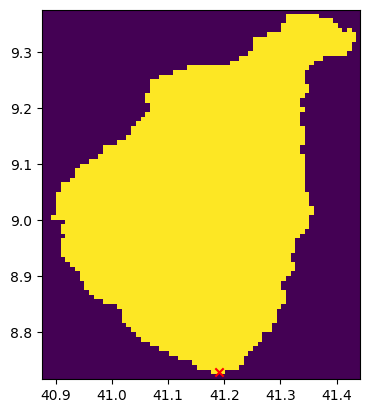

In [274]:
#plot_raster_file(fname_out)#, vmin=0, vmax=1)
#plot_raster_file(path_bsn_mask)#, show_colorbar=True, vmin=0, vmax=1)
plot_raster_file(path_bsn_mask_test)#, vmin=0, vmax=1)
plt.scatter(outlet['East'], outlet['North'], color='red', marker='x', label='Outlet')
#plt.legend(frameon=False)

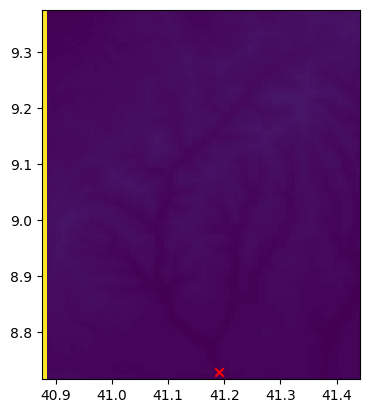

In [275]:
plot_raster_file(path_bsn_dem)#, show_colorbar=True)#, vmin=0, vmax=1)
plt.scatter(outlet['East'], outlet['North'], color='red', marker='x', label='Outlet')
#plt.legend(frameon=False)

Clip all raster files to match the model domain

#### 3. Create a JSON file with all model parameters

We are going to create a new JSON file using a template. You can create the template below in the CUWALID website:

https://cuwalid.github.io/tools/input-helper/

In [276]:
# read a default JSON file with empty values and fill it with the parameters for the basin delineation
path_json_template = "/home/c1755103/training/historical/basin/model/dryp_input_template.json"
with open(path_json_template, "r") as f:
    json_data = json.load(f)

In [277]:
# UPDATE the JSON file with the filename parameters from the continental Africa dataset
# this function searches for a key in a nested dictionary and returns the value associated with that key
def find_value_by_key(data, target_key):
    if isinstance(data, dict):
        if target_key in data:
            return True, data[target_key]
        for value in data.values():
            found, result = find_value_by_key(value, target_key)
            if found:
                return True, result
    elif isinstance(data, list):
        for item in data:
            found, result = find_value_by_key(item, target_key)
            if found:
                return True, result
    return False, None


def update_json_from_params(data, source_params):
    if isinstance(data, dict):
        for key, value in data.items():
            found, replacement = find_value_by_key(source_params, key)
            if isinstance(value, (dict, list)):
                update_json_from_params(value, source_params)
            elif found:
                data[key] = replacement
    elif isinstance(data, list):
        for item in data:
            update_json_from_params(item, source_params)
    return data

In [295]:
json_data = update_json_from_params(json_data, params)

# Take a look at the updated JSON data
# This should now contain the filename parameters from the continental Africa dataset,
# which will be used for the basin delineation and subsequent steps in the DRYP workflow
json_data

{'model_name': 'DRYP_model_sim',
 'path_input': '',
 'TERRAIN': {'path_dem': '/home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif',
  'path_Qo': None,
  'path_fdl': '/home/c1755103/AF/dataset/raw/hyd_af_dir_30s.tif',
  'path_riv_decay': None,
  'path_mask': '/home/c1755103/AF/dataset/raw/hyd_af_msk_30s.tif',
  'path_riv_len': '/home/c1755103/AF/dataset/postpp/af_river_length_30s.tif',
  'path_riv_width': '/home/c1755103/AF/dataset/postpp/af_river_width_30s.tif',
  'path_riv_elev': '/home/c1755103/AF/dataset/postpp/af_dem_30s_q1.tif'},
 'VEGETATION': {'path_veg_kc': None, 'path_veg_lulc': None},
 'UNSATURATED': {'path_uz_theta_sat': '/home/c1755103/AF/dataset/postpp/af_theta_s_l1.tif',
  'path_uz_theta_awc': '/home/c1755103/AF/dataset/postpp/af_theta_available_water_content.asc',
  'path_uz_theta_wp': '/home/c1755103/AF/dataset/postpp/af_theta_wilting_point.asc',
  'path_uz_rootdepth': '/home/c1755103/AF/dataset/postpp/gyga_af_agg_erzd_pwp__m_1km_reprojected.tif',
  'path_uz_lambda': '/hom

Now, we will create a new set of files for the basin scale model, including paramaters and model files.

In [296]:
# This function creates a new path for a file by adding a prefix to the original filename
#  and changing the directory to a new path
def create_new_path(current_path, new_prefix, new_path):
    # split the base path
    base_path = os.path.dirname(current_path)
    # the name of the json file without the path
    json_name = os.path.basename(current_path)
    # create the new name for the json file by adding the prefix to the original name
    new_name = new_prefix + json_name
    # create the full path for the new json file
    new_path = os.path.join(new_path, new_name)
    return new_name, new_path


Take a look at what will happen when the names will are changed with the function above:

In [297]:
# run a test of the function to create a new path for the json file with the parameters for the basin delineation

path_json_template = "/home/c1755103/training/historical/basin/model/dryp_input_template.json"

# especify prefix for the new file that will be created with the parameters for the basin delineation
new_prefix = "aw_"
new_path = directories[7]

new_name, new_path = create_new_path(path_json_template, new_prefix, new_path)

print("Base path:", os.path.dirname(path_json_template))
print("JSON name:", os.path.basename(path_json_template))
print("New JSON name:", new_name)
print("New JSON path:", new_path)



Base path: /home/c1755103/training/historical/basin/model
JSON name: dryp_input_template.json
New JSON name: aw_dryp_input_template.json
New JSON path: /home/c1755103/training_mowe/AW/model/input/aw_dryp_input_template.json


NOW! let's create the new set of files.

***The function below is able to do quite a lot of things so be careful about its use***

- Thus, the function is able to perform the following:
- Loop through all the fields of the JSON files
- Identify if the value of the file is a path
- Change the values of the fields if it is a path to a new path by adding the **new_prefix** at the beggining and - changing the directory to **target_dir**.
- CROP DATASETs if the option **crop_dataset** is active. This will CREATE new files by cropping all the files listed in the JSON file.

In [298]:
# loop through keys in the JSON file and return updated data without mutating the input
def update_json_values(data, new_prefix, target_dir, indent=0, crop_dataset=False, path_rgn_bsn_mask=None):
    """This function takes a nested data structure (dictionary or list) and updates
    the string values that represent file paths by creating new paths with a specified prefix
    and target directory. It also has an option to crop datasets to a region extent if the original path exists.
    
    Parameters:
    data: The input data structure (dictionary or list) to be updated.
    new_prefix: The prefix to be added to the original filename.
    target_dir: The directory where the new files will be saved.
    indent: The indentation level for printing the changes (used for nested structures).
    crop_dataset: A boolean flag indicating whether to crop the dataset to the region extent if the original path exists.
    path_rgn_bsn_mask: The path to the region basin mask used for cropping the dataset.
    """

    if isinstance(data, dict):
        new_data = {}
        for key, value in data.items():
            if isinstance(value, dict) or isinstance(value, list):
                new_data[key] = update_json_values(value, new_prefix, target_dir, indent + 4,
                                                   crop_dataset=crop_dataset, path_rgn_bsn_mask=path_rgn_bsn_mask)
            elif isinstance(value, str) and value.strip():
                new_name, new_value = create_new_path(value, new_prefix, target_dir)
                new_data[key] = new_value
                #print(' ' * indent + f"{key}: {value} -> {new_value}")
                # check if the original value path exists
                if os.path.exists(value):
                    if crop_dataset:
                        # if the original path exists and crop_dataset is True, crop it to the region extent
                        try:
                            rrtools.clip_raster_by_mask(value, path_rgn_bsn_mask, new_value)
                            print(f"Dataset {value} cropped successfully to {new_value}")
                        except Exception as e:
                            print(f"Error cropping dataset {value}: {e}")
            else:
                new_data[key] = value
        return new_data
    elif isinstance(data, list):
        new_data = []
        for index, item in enumerate(data):
            if isinstance(item, dict) or isinstance(item, list):
                new_data.append(update_json_values(item, new_prefix, target_dir, indent + 4,
                                                   crop_dataset=crop_dataset, path_rgn_bsn_mask=path_rgn_bsn_mask))
            elif isinstance(item, str) and item.strip():
                new_name, new_value = create_new_path(item, new_prefix, target_dir)
                new_data.append(new_value)
                #print(' ' * indent + f"[{index}]: {item} -> {new_value}")
                # check if the original item path exists
                if os.path.exists(item):
                    if crop_dataset:
                        # if the original path exists and crop_dataset is True, crop it to the region extent
                        try:
                            rrtools.clip_raster_by_mask(item, path_rgn_bsn_mask, new_value)
                            print(f"Dataset {item} cropped successfully to {new_value}")
                        except Exception as e:
                            print(f"Error cropping dataset {item}: {e}")
            else:
                new_data.append(item)
        return new_data
    return data

In [299]:
# Run the function to update the JSON data with the new paths for the files, and crop the
# datasets to the basin extent if the original paths exist
# THIS MAY ALSO CREATE NEW CROPPED DATASETS IN THE TARGET DIRECTORY IF THE ORIGINAL PATHS EXIST
new_prefix = "aw_"
json_data_updated = update_json_values(json_data, new_prefix, directories[7], crop_dataset=True, path_rgn_bsn_mask=path_rgn_mask)
#json_data_updated

Dataset /home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif cropped successfully to /home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dem_30s.tif
Dataset /home/c1755103/AF/dataset/raw/hyd_af_dir_30s.tif cropped successfully to /home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dir_30s.tif
Dataset /home/c1755103/AF/dataset/raw/hyd_af_msk_30s.tif cropped successfully to /home/c1755103/training_mowe/AW/model/input/aw_hyd_af_msk_30s.tif
Dataset /home/c1755103/AF/dataset/postpp/af_river_length_30s.tif cropped successfully to /home/c1755103/training_mowe/AW/model/input/aw_af_river_length_30s.tif
Dataset /home/c1755103/AF/dataset/postpp/af_river_width_30s.tif cropped successfully to /home/c1755103/training_mowe/AW/model/input/aw_af_river_width_30s.tif
Dataset /home/c1755103/AF/dataset/postpp/af_dem_30s_q1.tif cropped successfully to /home/c1755103/training_mowe/AW/model/input/aw_af_dem_30s_q1.tif
Dataset /home/c1755103/AF/dataset/postpp/af_theta_s_l1.tif cropped successfully to /home/c175

In [300]:
json_data_updated

{'model_name': '/home/c1755103/training_mowe/AW/model/input/aw_DRYP_model_sim',
 'path_input': '',
 'TERRAIN': {'path_dem': '/home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dem_30s.tif',
  'path_Qo': None,
  'path_fdl': '/home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dir_30s.tif',
  'path_riv_decay': None,
  'path_mask': '/home/c1755103/training_mowe/AW/model/input/aw_hyd_af_msk_30s.tif',
  'path_riv_len': '/home/c1755103/training_mowe/AW/model/input/aw_af_river_length_30s.tif',
  'path_riv_width': '/home/c1755103/training_mowe/AW/model/input/aw_af_river_width_30s.tif',
  'path_riv_elev': '/home/c1755103/training_mowe/AW/model/input/aw_af_dem_30s_q1.tif'},
 'VEGETATION': {'path_veg_kc': None, 'path_veg_lulc': None},
 'UNSATURATED': {'path_uz_theta_sat': '/home/c1755103/training_mowe/AW/model/input/aw_af_theta_s_l1.tif',
  'path_uz_theta_awc': '/home/c1755103/training_mowe/AW/model/input/aw_af_theta_available_water_content.asc',
  'path_uz_theta_wp': '/home/c1755103/trainin

Add observation points to the json file

In [301]:
obs_points = {'East': [41.19, 41.1], 'North': [8.73, 8.8]} # outlet coordinates for the Awash and Genale basins, respectively

In [302]:
# create a dataframe from the dictionary and save it as a csv file
import pandas as pd
df_observation_points = pd.DataFrame([obs_points['East'], obs_points['North']]).T
df_observation_points.columns = ['East', 'North']
# save the dataframe as a csv file in the output directory
fname_obs = os.path.join(directories[7], "test_observation_points.csv")
print(f"Saving observation points to: {fname_obs}")
df_observation_points.to_csv(fname_obs, index=False)

df_observation_points

Saving observation points to: /home/c1755103/training_mowe/AW/model/input/test_observation_points.csv


,East,North
0,41.19,8.73
1,41.10,8.80


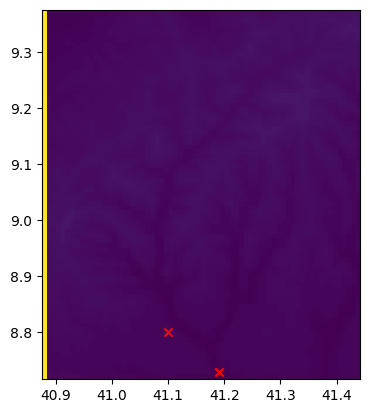

In [303]:
plot_raster_file(path_bsn_dem)#, vmin=0, vmax=1)
plt.scatter(obs_points['East'], obs_points['North'], color='red', marker='x', label='Outlet')

You will also need to prepare the DRYP model setting file. You can create this file by using the CUWALID Input Helper (https://cuwalid.github.io/tools/input-helper/), or you can create one by yourself. Yeah, use the input helper, it is easier!

Here we have already created the DRYP settings JSON file, but we are going to make some updates for you, remember, you can also modify this in the Input Helper.

In [287]:
#path_json_settings = os.path.join(directories[7], "aw_dryp_input_settings.json")
path_json_settings = '/home/c1755103/training/historical/basin/model/dryp_settings_template.json'
with open(path_json_settings, "r") as f:
    json_settings = json.load(f)

json_settings

{'SIMULATION_PERIOD': {'start_date': '2024 1 1', 'end_date': '2024 12 30'},
 'GEOGRAPHIC_SYSTEM': True,
 'PROJECTION': 'EPSG:4326',
 'FLOWDIR_FORMAT': 'DRYP',
 'TIMESTEP_SETTINGS': {'dt_of': 60, 'dt_uz': 60, 'dt_gw': 60},
 'READING': {'data_reading': {'pre': 3,
   'pet': 2,
   'kc': 3,
   'savi': 3,
   'fluxOF': 0,
   'fluxUZ': 0,
   'fluxSZ': 0,
   'fluxWB': 0,
   'av': 0,
   'lai': 3},
  'data_step': {'pre': 30, 'pet': 60, 'kc': 1440, 'savi': 1440, 'lai': 1440},
  'data_reproject': {'pre': False,
   'pet': False,
   'kc': False,
   'savi': False,
   'lai': False},
  'data_interp': {'pre': True,
   'pet': True,
   'kc': False,
   'savi': False,
   'lai': False},
  'data_projection': {'pre': 'EPSG:4326',
   'pet': 'EPSG:4326',
   'kc': 'EPSG:4326',
   'savi': 'EPSG:4326',
   'lai': 'EPSG:4326'}},
 'COMPONENTS': {'method_inf': 1, 'run_gw': True, 'method_gw': 2},
 'OUTPUT': {'output_csv': True,
  'output_grid': True,
  'output_grid_rmax': False,
  'output_grid_vmax': False,
  'output_dt_

Let's make some changes to this file, and store the updated file.

In [288]:
json_settings['READING']['data_reading']['pre'] = 3
json_settings['READING']['data_reading']['pet'] = 2

# save the updated JSON file with the parameters for the basin delineation
with open(path_json_settings, "w") as f:
    json.dump(json_settings, f, indent=4)
    

You will need to modify and add more information to the JSON file in order to run the model

In [308]:
# modify the model name
json_data_updated['model_name'] = 'aw_simulation_01'
# change the model mask path to the new basin mask
json_data_updated['TERRAIN']['path_mask'] = path_bsn_mask_test
# modify model outputs directory
json_data_updated['OUTPUT']['path_output'] = directories[0]
# moddify settings path
json_data_updated['OUTPUT']['path_setting'] = path_json_settings
# path for the observation points csv file
json_data_updated['OUTPUT']['path_out_oz'] = fname_obs
json_data_updated['OUTPUT']['path_out_uz'] = fname_obs
json_data_updated['OUTPUT']['path_out_sz'] = fname_obs
# set forcing paths
json_data_updated['METEO']['path_pre'] = "/share/home/c1755103/dataset/IMERG/YYYY/IMERG_YYYY-MM.nc"
json_data_updated['METEO']['path_pet'] = "/share/home/c1755103/dataset/ERA/HAD_pet_H_YYYY.nc"

# store the updated JSON data in a new file
new_json_path = os.path.join(directories[7], "aw_dryp_input.json")

print("New JSON path:", new_json_path)

with open(new_json_path, "w") as f:
    json.dump(json_data_updated, f, indent=4)

#json_data_updated

New JSON path: /home/c1755103/training_mowe/AW/model/input/aw_dryp_input.json


Take a look to the new datasets created.

Use the following function to plot all maps available in the JSON file:

In [309]:
# loop through all the values in the JSON file and check if they are valid paths, if so, plot the raster files
def plot_raster_paths_in_json(data, indent=0):
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, dict) or isinstance(value, list):
                plot_raster_paths_in_json(value, indent + 4)
            elif isinstance(value, str) and value.strip():
                if os.path.exists(value):
                    # check if the file is a raster file by checking the extension
                    if value.lower().endswith(('.tif', '.tiff', '.nc', '.hdf', '.img')):
                        try:
                            plot_raster_file(value, show_colorbar=True, title=key)
                            print(' ' * indent + f"{key}: {value} (plotted)")
                        except Exception as e:
                            print(f"Error plotting raster file {value}: {e}")
                    else:
                        print(' ' * indent + f"{key}: {value} (does not exist)")
    elif isinstance(data, list):
        for index, item in enumerate(data):
            if isinstance(item, dict) or isinstance(item, list):
                plot_raster_paths_in_json(item, indent + 4)
            elif isinstance(item, str) and item.strip():
                if os.path.exists(item):
                    # check if the file is a raster file by checking the extension
                    if item.lower().endswith(('.tif', '.tiff', '.nc', '.hdf', '.img')):
                        try:
                            plot_raster_file(item, show_colorbar=True, title=f"[{index}]")
                            print(' ' * indent + f"[{index}]: {item} (plotted)")
                        except Exception as e:
                            print(f"Error plotting raster file {item}: {e}")
                    else:
                        print(' ' * indent + f"[{index}]: {item} (does not exist)")

    path_dem: /home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dem_30s.tif (plotted)
    path_fdl: /home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dir_30s.tif (plotted)
    path_mask: /home/c1755103/training_mowe/AW/model/input/aw_test_basin_mask_check.tif (plotted)
    path_riv_len: /home/c1755103/training_mowe/AW/model/input/aw_af_river_length_30s.tif (plotted)
    path_riv_width: /home/c1755103/training_mowe/AW/model/input/aw_af_river_width_30s.tif (plotted)
    path_riv_elev: /home/c1755103/training_mowe/AW/model/input/aw_af_dem_30s_q1.tif (plotted)
    path_uz_theta_sat: /home/c1755103/training_mowe/AW/model/input/aw_af_theta_s_l1.tif (plotted)
    path_uz_theta_awc: /home/c1755103/training_mowe/AW/model/input/aw_af_theta_available_water_content.asc (does not exist)
    path_uz_theta_wp: /home/c1755103/training_mowe/AW/model/input/aw_af_theta_wilting_point.asc (does not exist)
    path_uz_rootdepth: /home/c1755103/training_mowe/AW/model/input/aw_gyga_af_agg_erzd_pwp__m_

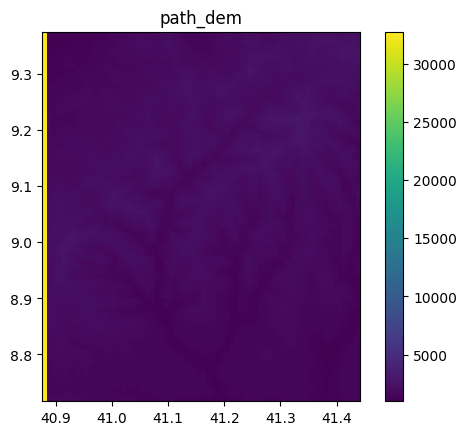

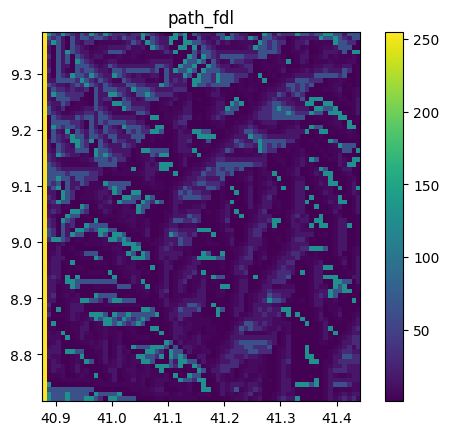

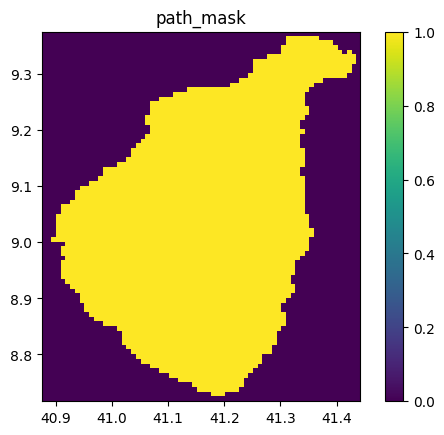

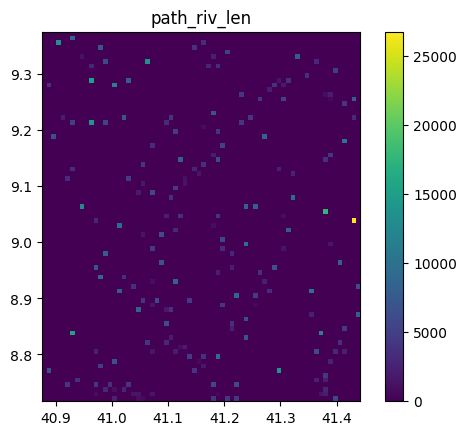

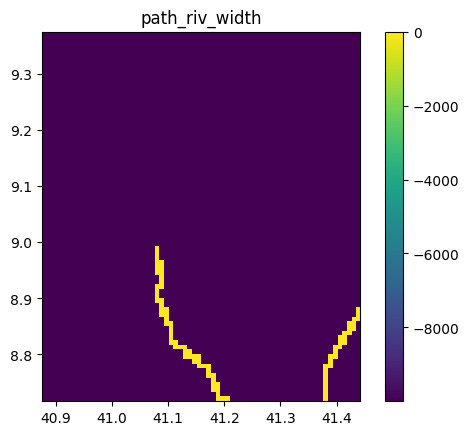

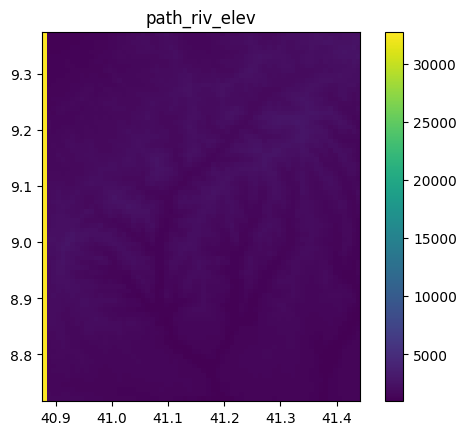

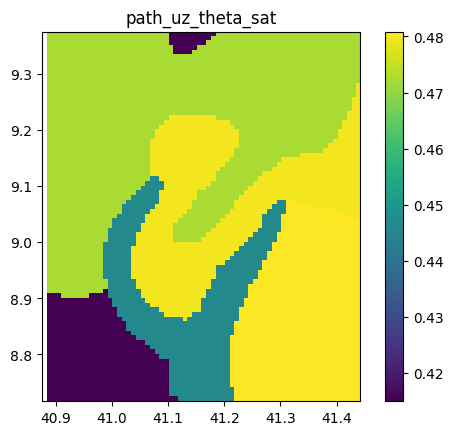

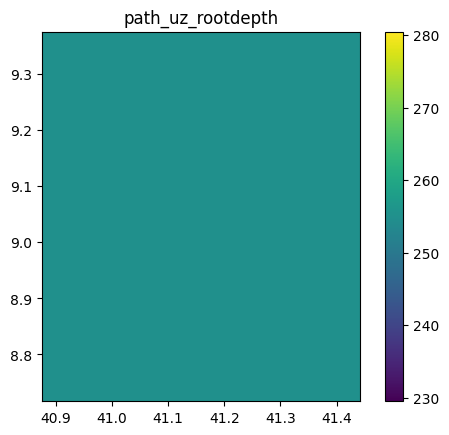

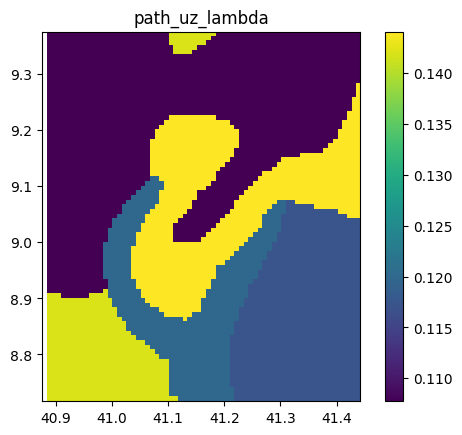

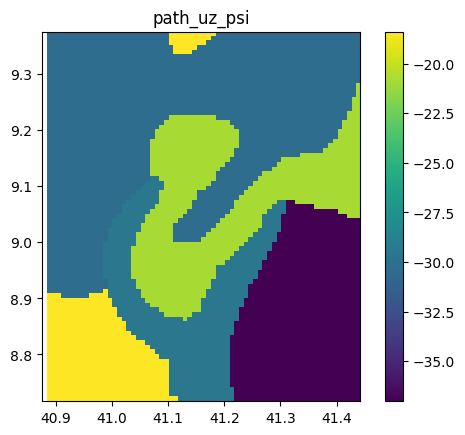

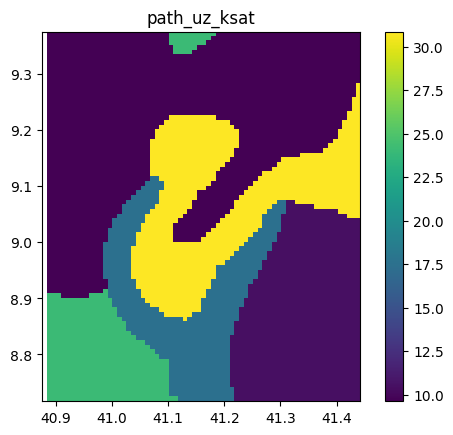

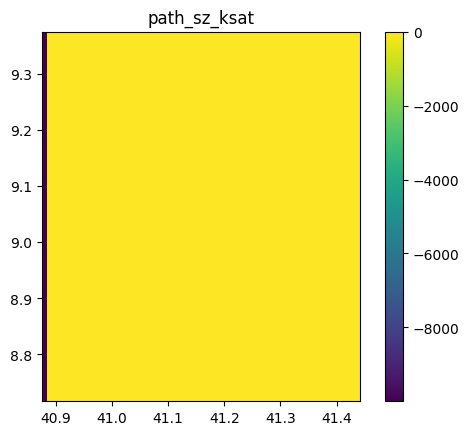

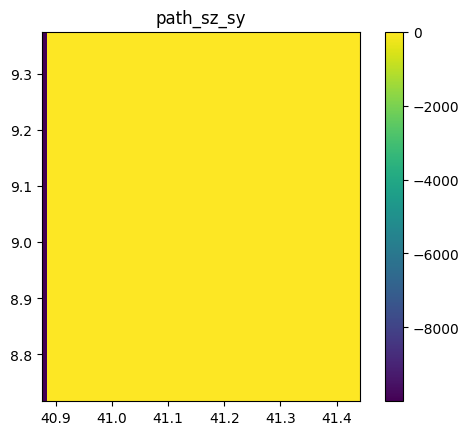

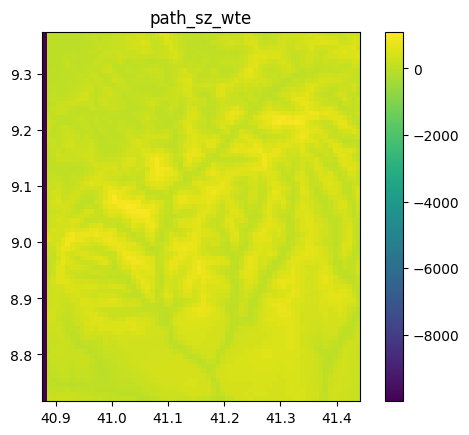

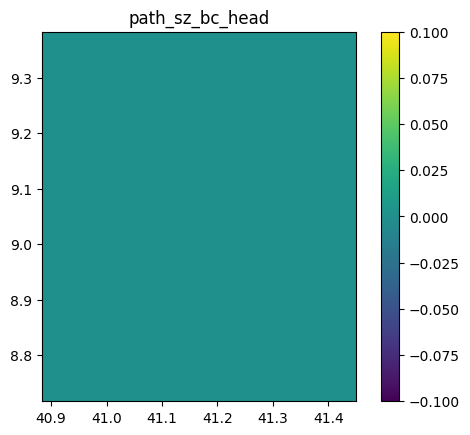

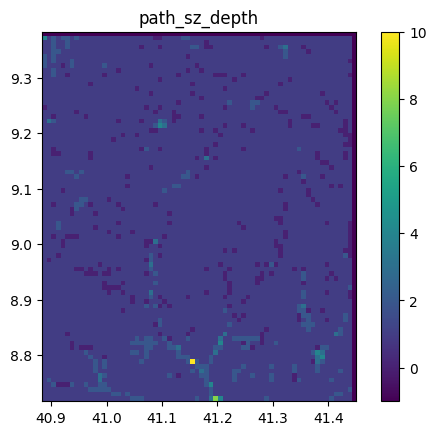

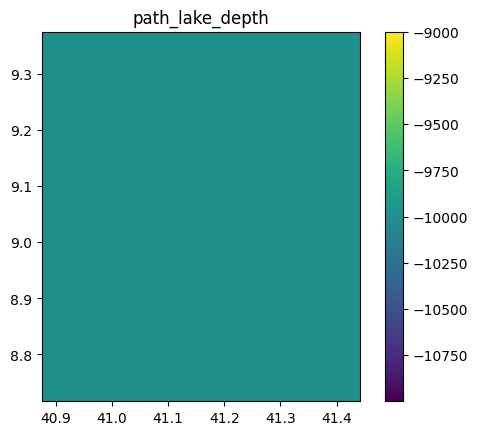

In [310]:
plot_raster_paths_in_json(json_data_updated)

In [292]:

# chek if the saved raster has the same shape and bounds as the reference raster
def check_raster_match(out_path, ref_path):
    with rasterio.open(out_path) as dst:
        out_bounds = dst.bounds
        out_width = dst.width
        out_height = dst.height

    # check if the saved raster has the same shape and bounds as the reference raster
    with rasterio.open(ref_path) as ref:
        ref_bounds = ref.bounds
        ref_width = ref.width
        ref_height = ref.height

    if (out_bounds == ref_bounds) and (out_width == ref_width) and (out_height == ref_height):
        print("Ok")
    else:
        print("The saved raster does not match the reference raster.")

In [293]:
RASTER_EXTENSIONS = {'.tif', '.tiff', '.asc', '.nc', '.img', '.vrt', '.hdf', '.h5'}

# Loop through the raster paths in the updated JSON data and check if they match the reference rasters
def check_raster_paths_in_json(data, ref_path, indent=0):
    if isinstance(data, dict):
        for key, value in data.items():
            if isinstance(value, dict) or isinstance(value, list):
                check_raster_paths_in_json(value, ref_path, indent + 4)
            elif isinstance(value, str) and value.strip():
                if os.path.exists(value):
                    if os.path.splitext(value)[1].lower() not in RASTER_EXTENSIONS:
                        print(' ' * indent + f"{key}: {value} (skipped, not a raster)")
                        continue
                    if os.path.exists(ref_path):
                        print(' ' * indent + f"{key}: {value} (checking against reference: {ref_path})")
                        check_raster_match(value, ref_path)
                    else:
                        print(' ' * indent + f"{key}: {value} (reference raster does not exist: {ref_path})")
                else:
                    print(' ' * indent + f"{key}: {value} (does not exist)")
    elif isinstance(data, list):
        for index, item in enumerate(data):
            if isinstance(item, dict) or isinstance(item, list):
                check_raster_paths_in_json(item, ref_path, indent + 4)
            elif isinstance(item, str) and item.strip():
                if os.path.exists(item):
                    if os.path.splitext(item)[1].lower() not in RASTER_EXTENSIONS:
                        print(' ' * indent + f"[{index}]: {item} (skipped, not a raster)")
                        continue
                    if os.path.exists(ref_path):
                        print(' ' * indent + f"[{index}]: {item} (checking against reference: {ref_path})")
                        check_raster_match(item, ref_path)
                    else:
                        print(' ' * indent + f"[{index}]: {item} (reference raster does not exist: {ref_path})")
                else:
                    print(' ' * indent + f"[{index}]: {item} (does not exist)")

In [294]:
check_raster_paths_in_json(json_data_updated, path_bsn_dem)

model_name: aw_simulation_01 (does not exist)
    path_dem: /home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dem_30s.tif (checking against reference: /home/c1755103/training_mowe/AW/model/input/aw_test_basin_dem.tif)
Ok
    path_fdl: /home/c1755103/training_mowe/AW/model/input/aw_hyd_af_dir_30s.tif (checking against reference: /home/c1755103/training_mowe/AW/model/input/aw_test_basin_dem.tif)
Ok
    path_mask: /home/c1755103/training_mowe/AW/model/input/aw_test_basin_mask_check.tif (checking against reference: /home/c1755103/training_mowe/AW/model/input/aw_test_basin_dem.tif)
Ok
    path_riv_len: /home/c1755103/training_mowe/AW/model/input/aw_af_river_length_30s.tif (checking against reference: /home/c1755103/training_mowe/AW/model/input/aw_test_basin_dem.tif)
Ok
    path_riv_width: /home/c1755103/training_mowe/AW/model/input/aw_af_river_width_30s.tif (checking against reference: /home/c1755103/training_mowe/AW/model/input/aw_test_basin_dem.tif)
Ok
    path_riv_elev: /home/c175510

#### 4. Set forcing datasets

HYDROSHED basins

In [ ]:
# a list of station names for which we want to perform the basin delineation
path_shape_pour_point = "/share/home/c1755103/dataset/HYDROSHEDS/hybas_pour_lev04_v1.shp"

In [ ]:
import geopandas as gpd
# open the shapefile with the pour points
pour_points = gpd.read_file(path_shape_pour_point)

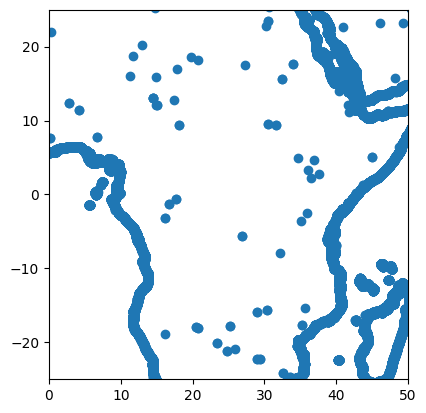

In [ ]:
pour_points.plot()#.head()
plt.xlim([0,50])
plt.ylim([-25,25])
plt.show()


In [ ]:
# select the pour point for the basin of interest (e.g., the first one in the shapefile)
pour_point = pour_points.iloc[0]
print(pour_point)


In [ ]:
# createa csv file with the pour point coordinates
import pandas as pd
#pour_point_df = pd.DataFrame({'lon': [pour_point.geometry.x], 'lat': [pour_point.geometry.y]})
#pour_point_df.to_csv(os.path.join(training_basin_vector_path, "pour_point.csv"), index=False)
training_basin_vector_path = "/home/c1755103/training/historical/basin/dataset/csv"
pour_point_df = pd.DataFrame({'East': [45.0], 'North': [6.5]})
path_af_outlet = os.path.join(training_basin_vector_path, "pour_point.csv")
pour_point_df.to_csv(path_af_outlet, index=False)

path_test = "/home/c1755103/training/test_delete_after/"
fname_out = os.path.join(path_test, "test_basin_pour_point.asc")
